# Vision AI Agent | Playground
To Do:
- Agent
- RAG
- Proper structure
- Documentation - technical writing
- Demo video

____

In [1]:
from backend.app.agent import VisionAIOSHAgent
from PIL import Image

# import os
# from dotenv import load_dotenv
# load_dotenv()  # Load environment variables from .env file

/Users/egorfolley/TechDev/.env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
# g_api_key = os.environ.get("GOOGLE_API_KEY")

import os
import io
import json
import google.generativeai as genai
from typing import List, Dict
from PIL import Image, ImageDraw, ImageFont
from langchain_community.document_loaders import PyPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
import re
import pathlib

from dotenv import load_dotenv
load_dotenv()


class VisionAIOSHAgent__:
    def __init__(
        self,
        persist_dir: str = "backend/RAG_vectorDB"
    ):
       # Gemini setup
        g_api_key = os.environ.get("GOOGLE_API_KEY")
        self.api_key = g_api_key or os.getenv("GOOGLE_API_KEY", g_api_key)
        
        genai.configure(api_key=self.api_key)
        self.model = genai.GenerativeModel("gemini-2.5-flash", 
                                           generation_config={"temperature": 0})

        self.persist_dir = persist_dir

        # RAG — build once, then just connect
        self._setup_rag()


    def _setup_rag(self):
        embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

        # Loading vectorstore
        vectorstore = Chroma(
            persist_directory=self.persist_dir,
            embedding_function=embeddings
        )
        self.retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

        total_documents = vectorstore._collection.count()
        print(f"Total documents in vectorstore: {total_documents}")


    def get_osha_reference(self, description: str) -> str:
        docs = self.retriever.invoke(description)
        return "\n\n".join(doc.page_content for doc in docs)


    @staticmethod
    def _pil_to_genai_image(pil_img: Image.Image):
        buf = io.BytesIO()
        pil_img.save(buf, format="JPEG")
        buf.seek(0)
        return genai.upload_file(buf, mime_type="image/jpeg")


    @staticmethod
    def _draw_violations(image: Image.Image, violations: List[Dict]) -> Image.Image:
        img = image.convert("RGBA")
        overlay = Image.new("RGBA", 
                            img.size, 
                            (0,0,0,0))
        draw = ImageDraw.Draw(overlay)
        
        font = ImageFont.load_default(size=20)
        colors = ["#FF3333", "#33AA33", "#4444FF"]

        for i, v in enumerate(violations):
            box = v.get("bounding_box")
            if not box or len(box) != 4: continue
            x1,y1,x2,y2 = box
            
            if max(box) <= 1.0:
                w,h = image.size
                x1, y1, x2, y2 = int(x1*w), int(y1*h), int(x2*w), int(y2*h)

            color = colors[i % len(colors)]
            draw.rectangle([x1,y1,x2,y2], outline=color, width=7)

            code = v.get("code", "001")
            desc = v.get("title", "")

            # Show code only if RAG matched it
            if "NO CODE" not in code:
                draw.rectangle([x1, y1-55, x1+len(code)*13+20, y1-30], fill=color)
                draw.text((x1+10, y1-52), code, fill="white", font=font)

            draw.rectangle([x1, y1-28, x1+len(desc)*10+20, y1-5], fill=color)
            draw.text((x1+10, y1-25), desc, fill="white", font=font)

        return Image.alpha_composite(img, overlay).convert("RGB")


    def analyze(self, image: Image.Image) -> tuple[List[Dict], Image.Image]:
        genai_img = self._pil_to_genai_image(image)

        prompt = """You are an expert OSHA construction safety inspector with 20 years of field experience.

        Your job is to save lives — never miss a serious violation.

        Analyze this image and detect ALL visible OSHA violations.

        Rules:
        - Only report what you clearly see
        - Multiple workers = multiple violations
        - Be specific but short in description
        - Bounding box must tightly fit the violation (person, object, area)
        - Coordinates in pixels

        Return ONLY this exact JSON — nothing else, no markdown, no explanations:

        {
        "violations": [
            {
            "description": "<describe here the violation>",
            "bounding_box": [x_min, y_min, x_max, y_max]
            },
            {
            "description": "<describe here the violation>",
            "bounding_box": [x_min, y_min, x_max, y_max]
            }
        ]
        }

        If no violations → return: {"violations": []}
        """

        response = self.model.generate_content([prompt, genai_img])

        # Parse LLM output
        text = response.text.strip().replace("```json", "").replace("```", "").strip()
        try:
            data = json.loads(text)
            detected_violations = data.get("violations", [])
        except:
            import re
            match = re.search(r'\[\s*{.*}\s*\]', text, re.DOTALL)
            detected_violations = json.loads(match.group()) if match else []

        # RAG-enhanced violations 
        enriched_violations = []
        for v in detected_violations:
            desc = v.get("description", "").lower().strip()
            bbox = v.get("bounding_box")

            if not desc or not bbox or len(bbox) != 4:
                continue

            results = self.retriever.invoke(desc)
            matched_code = None
            matched_title = None
            matched_text = None

            for doc in results:
                title = doc.metadata.get("title", "").lower()
                if any(word in title for word in desc.split() if len(word) > 3):
                    matched_code = doc.metadata.get("code")
                    matched_title = doc.metadata.get("title")
                    matched_text = doc.page_content
                    break

            violation = {
                "description": v["description"],
                "bounding_box": bbox
            }

            if matched_code:
                violation["code"] = matched_code
                violation["title"] = matched_title
                violation["osha_reference"] = matched_text[:800]

            enriched_violations.append(violation)

        # NEW: Deduplicate by OSHA code — keep only ONE entry per code
        seen_codes = set()
        final_violations = []

        for v in enriched_violations:
            code = v.get("code")
            if code and code not in seen_codes:
                seen_codes.add(code)
                final_violations.append(v)
            elif not code:
                # Keep unmatched violations (no code)
                final_violations.append(v)

        # Draw
        annotated = self._draw_violations(image, final_violations)
        return final_violations, annotated

In [28]:
agent = VisionAIOSHAgent__()  # Builds RAG if needed

Total documents in vectorstore: 20


In [29]:
img_path = "backend/data/input_data/test.jpg"

img_pil = Image.open(img_path)

In [30]:
res, vis_img = agent.analyze(img_pil)

In [31]:
res

[{'description': 'Worker is climbing the scaffold frame structure instead of using a ladder or other safe means of access.',
  'bounding_box': [300, 100, 700, 999],
  'code': '1926.451(e)(1)',
  'title': 'Scaffolding - Access',
  'osha_reference': 'When scaffold platforms are more than 2 feet above or below a point of access, portable ladders, hook-on ladders, or stair towers shall be used.'},
 {'description': "Worker's fall protection lanyard is not connected to an anchorage point, rendering fall protection ineffective.",
  'bounding_box': [390, 350, 600, 800],
  'code': '1926.501(b)(1)',
  'title': 'Fall protection - Unprotected sides and edges',
  'osha_reference': 'Each employee on a walking/working surface 6 feet or more above lower levels shall be protected from falling by guardrail systems, safety nets, or personal fall arrest systems.'}]

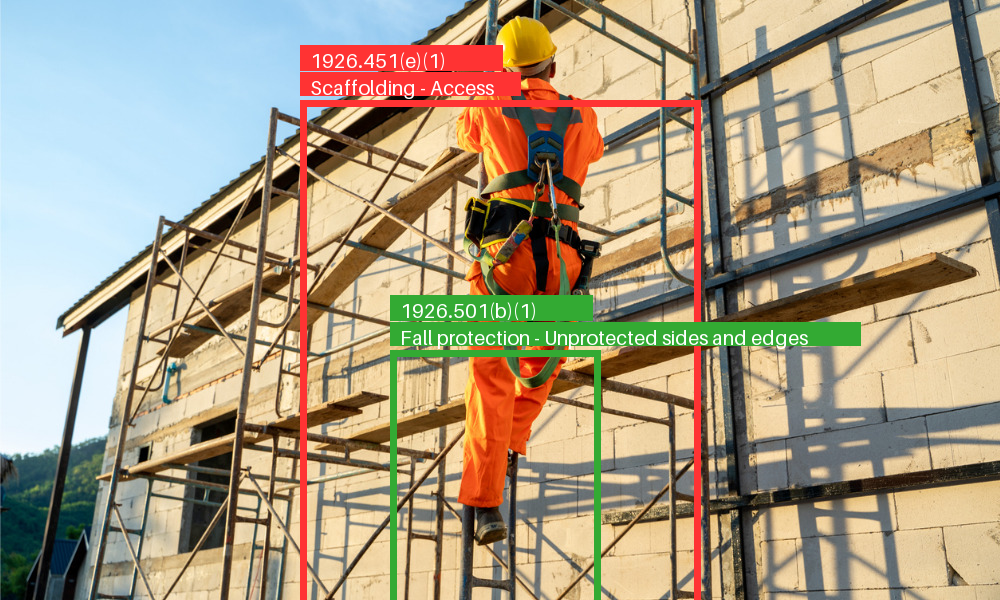

In [32]:
vis_img

## RAG enrichment

In [ ]:
json_rag_input = [
  {"id": "1926.501(b)(1)", "title": "Fall protection - Unprotected sides and edges", "text": "Each employee on a walking/working surface 6 feet or more above lower levels shall be protected from falling by guardrail systems, safety nets, or personal fall arrest systems."},
  {"id": "1926.100(a)", "title": "Head protection", "text": "Employees shall be provided with and required to wear protective helmets when working in areas where there is a potential for injury to the head from falling or flying objects."},
  {"id": "1926.102(a)(1)", "title": "Eye and face protection", "text": "The employer shall ensure that each affected employee uses appropriate eye or face protection when exposed to eye or face hazards."},
  {"id": "1926.1053(b)(1)", "title": "Ladders - Top of ladder not extended 3 feet", "text": "When portable ladders are used for access to an upper landing surface, the ladder side rails shall extend at least 3 feet above the upper landing surface."},
  {"id": "1926.451(e)(1)", "title": "Scaffolding - Access", "text": "When scaffold platforms are more than 2 feet above or below a point of access, portable ladders, hook-on ladders, or stair towers shall be used."},
  {"id": "1926.503(a)(1)", "title": "Fall protection training", "text": "The employer shall provide a training program for each employee who might be exposed to fall hazards."},
  {"id": "1926.451(g)(1)", "title": "Scaffold fall protection", "text": "Each employee on a scaffold more than 10 feet above a lower level shall be protected from falling to that lower level."},
  {"id": "1926.1053(b)(22)", "title": "Ladders - Used only for intended purpose", "text": "Ladders shall not be used for any purpose other than that for which they were designed."},
  {"id": "1926.20(b)(1)", "title": "General safety and health provisions", "text": "The employer shall initiate and maintain such programs as may be necessary to comply with this part."},
  {"id": "1926.651(k)(1)", "title": "Excavations - Daily inspections", "text": "Daily inspections of excavations shall be made by a competent person."},
  {"id": "1926.404(f)(6)", "title": "Grounding path", "text": "The path to ground from circuits, equipment, and enclosures shall be permanent and continuous."},
  {"id": "1926.1052(c)(1)", "title": "Stairways - Handrails", "text": "Stairways having four or more risers shall be equipped with standard stair railings or handrails."},
  {"id": "1926.1101", "title": "Asbestos", "text": "Requirements for construction work involving asbestos exposure."},
  {"id": "1926.62", "title": "Lead", "text": "Requirements for construction work involving lead exposure to lead."},
  {"id": "1926.416(a)(1)", "title": "Electrical - Protection of employees", "text": "No employer shall permit an employee to work in such proximity to any part of an electric power circuit that the employee could contact it."},
  {"id": "1926.701(b)", "title": "Concrete - Impalement protection", "text": "All protruding reinforcing steel onto which employees could fall shall be guarded to eliminate the hazard of impalement."},
  {"id": "1926.602(a)(9)(ii)", "title": "Seat belts on heavy equipment", "text": "Seat belts shall be provided on all equipment covered by this section."},
  {"id": "1926.95(a)", "title": "High-visibility clothing", "text": "Employees exposed to vehicular traffic shall wear high-visibility garments."},
  {"id": "1926.453(b)(2)(v)", "title": "Aerial lifts - Fall protection", "text": "A personal fall arrest or travel restraint system shall be worn and attached when working from an aerial lift."},
  {"id": "1926.405(a)(2)(ii)(I)", "title": "Flexible cords used with temporary power", "text": "Flexible cords shall be used only in continuous lengths without splice or tap."}
]

In [2]:
# Prepare texts & metadata from your list
from backend.app.rag import RAGVectorDBManager

rag_manager = RAGVectorDBManager(persist_dir="backend/RAG_vectorDB")

# texts = [item["text"] for item in json_rag_input if item.get("text")]
# metadatas = [
#     {"code": item.get("id"), "title": item.get("title"), "source": "inline_json"}
#     for item in json_rag_input if item.get("text")
# ]

# mgr = RAGVectorDBManager(persist_dir="backend/RAG_vectorDB")
# mgr.add_raw_texts(texts=texts, metadatas=metadatas)


Loading existing vector DB from backend/RAG_vectorDB


/Users/egorfolley/TechDev/vision_ai_agent/backend/app/rag.py:22: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  self.db = Chroma(persist_directory=self.persist_dir, embedding_function=self.embeddings)


In [ ]:
num_docs = len(rag_manager.db.get()['ids'])
print(f"Number of documents in RAG: {num_docs}")

Number of documents in RAG: 20


In [8]:
retr = rag_manager.get_retriever()

# Access the vectorstore and get all documents
all_data = retr.vectorstore.get()
documents = all_data['documents']
metadatas = all_data['metadatas']

if documents:
    # Get the random document text and metadata
    random_doc_text = documents[1]
    random_doc_metadata = metadatas[1]
    
    print(f"Random document: {random_doc_text}")
    print(f"Metadata: {random_doc_metadata}")
else:
    print("No documents found in the vectorstore.")

Random document: Employees shall be provided with and required to wear protective helmets when working in areas where there is a potential for injury to the head from falling or flying objects.
Metadata: {'code': '1926.100(a)', 'source': 'inline_json', 'title': 'Head protection'}


In [ ]:
# Display one specific example from the RAG documents
example_index = 0  # Choose an index, e.g., 0 for the first document

print(f"Document ID: {all_data['ids'][example_index]}")
print(f"Text: {documents[example_index]}")
print(f"Metadata: {metadatas[example_index]}")

Document ID: 90483d99-191a-4d14-82ca-6deefe1bd5eb
Text: Each employee on a walking/working surface 6 feet or more above lower levels shall be protected from falling by guardrail systems, safety nets, or personal fall arrest systems.
Metadata: {'code': '1926.501(b)(1)', 'title': 'Fall protection - Unprotected sides and edges', 'source': 'inline_json'}


## Accessing SQL

In [ ]:
import os
import io
from PIL import Image
import base64
from sqlalchemy import create_engine, text

In [ ]:
DATABASE_URL = os.getenv("DATABASE_URL")
if not DATABASE_URL:
    print("Error: Set DATABASE_URL in .env")
    exit()

engine = create_engine(DATABASE_URL)

print("Your saved OSHA inspections:\n" + "="*60)

with engine.connect() as conn:
    results = conn.execute(text("""
        SELECT id, created_at, original_filename, violations_count, violations 
        FROM inspections 
        ORDER BY created_at DESC
    """))

    for row in results:
        id, date, filename, count, violations = row
        print(f"ID: {id}")
        print(f"Date: {date.strftime('%Y-%m-%d %H:%M')}")
        print(f"File: {filename}")
        print(f"Violations found: {count}")
        print("Violations:")
        for v in violations[:3]:  # Show first 3
            code = v.get("code", "—")
            desc = v.get("description", "")
            print(f"   • {code} → {desc}")
        if len(violations) > 3:
            print(f"   ... and {len(violations)-3} more")
        print("-" * 60)

        # Optional: Show annotated image
        show = input("Show annotated image? (y/n): ")
        if show.lower() == "y":
            img_data = conn.execute(text("SELECT image_processed FROM inspections WHERE id = :id"), {"id": id}).scalar()
            img = Image.open(io.BytesIO(img_data))
            img.show()  # Opens in your default image viewer

print(f"\nTotal inspections: {results.rowcount}")
print("Done!")